In [11]:
from typing import TypedDict
from langgraph.graph import StateGraph, END, START
from langchain_google_genai import ChatGoogleGenerativeAI
from IPython.display import Image, display
# Define shared state between nodes
class OnboardingPlanState(TypedDict):
    role: str
    training: str
    tasks: str
    challenges: str
    summary: str

In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [6]:
def identify_training(state: OnboardingPlanState):
    response = llm.invoke(f"What core training areas should be covered for a new {state['role']}?")
    return {"training": response.content}

def suggest_tasks(state: OnboardingPlanState):
    response = llm.invoke(f"What onboarding tasks should be assigned to a new {state['role']}?")
    return {"tasks": response.content}

def analyze_challenges(state: OnboardingPlanState):
    response = llm.invoke(f"What common challenges do new {state['role']} hires face during onboarding?")
    return {"challenges": response.content}

def summarize_plan(state: OnboardingPlanState):
    prompt = f"""
    Onboarding Plan Summary for {state['role']}:
    - Training Needs: {state.get('training')}
    - Suggested Tasks: {state.get('tasks')}
    - Potential Challenges: {state.get('challenges')}
    Create a structured onboarding strategy based on the above.
    """
    response = llm.invoke(prompt)
    return {"summary": response.content}

In [7]:
graph_builder = StateGraph(OnboardingPlanState)

graph_builder.add_node("identify_training", identify_training)
graph_builder.add_node("suggest_tasks", suggest_tasks)
graph_builder.add_node("analyze_challenges", analyze_challenges)
graph_builder.add_node("summarize_plan", summarize_plan)

In [8]:
# Parallel start
graph_builder.add_edge(START, "identify_training")
graph_builder.add_edge(START, "suggest_tasks")
graph_builder.add_edge(START, "analyze_challenges")

# Converge into summarization
graph_builder.add_edge("identify_training", "summarize_plan")
graph_builder.add_edge("suggest_tasks", "summarize_plan")
graph_builder.add_edge("analyze_challenges", "summarize_plan")

In [9]:
graph = graph_builder.compile()

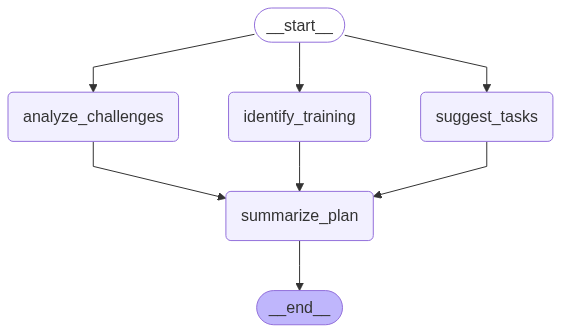

In [12]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
# Provide input
inputs = {"role": "Product Manager"}

# Execute graph
result = graph.invoke(inputs)

print("\n=== Final Onboarding Plan ===\n")
print(result["summary"])


=== Final Onboarding Plan ===

This structured onboarding strategy for a new Product Manager is designed to be comprehensive, addressing the identified training needs, integrating key tasks, and proactively mitigating potential challenges. It follows a 30-60-90 day framework, allowing for progressive immersion and increasing responsibility.

---

## Structured Onboarding Strategy for a New Product Manager

**Overall Goal:** To equip a new Product Manager with the foundational knowledge, strategic understanding, practical skills, and necessary relationships to become a fully productive and contributing member of the product team within 90 days, fostering confidence and a sense of ownership.

**Key Principles Guiding This Strategy:**

*   **Structured & Progressive:** A clear, phased plan with defined goals for each period.
*   **Balance Learning with Doing:** Mix deep dives, theoretical learning, and hands-on application.
*   **Mentorship & Support:** Provide dedicated guidance and a s